## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'normalization' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)

### Converting to tensors

In [19]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [20]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [21]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [22]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [23]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [24]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [25]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [26]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [27]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [28]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [29]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.35468754172325134 test 0.3567091374634168
EPOCH 2:
LOSS train 0.35056935126582783 test 0.3525918778891747
EPOCH 3:
LOSS train 0.3453033020099004 test 0.34876762164326813
EPOCH 4:
LOSS train 0.3418895707776149 test 0.34501744913749205
EPOCH 5:
LOSS train 0.3388255201280117 test 0.3413454458308526
EPOCH 6:
LOSS train 0.3378486546377341 test 0.3377593406882042
EPOCH 7:
LOSS train 0.3337479854623477 test 0.3342321973771621
EPOCH 8:
LOSS train 0.32795787913103897 test 0.33073926992141284
EPOCH 9:
LOSS train 0.32618465833365917 test 0.3272606015587464
EPOCH 10:
LOSS train 0.3228771599630515 test 0.32379012847175964
EPOCH 11:
LOSS train 0.32234380518396694 test 0.32034128833657655
EPOCH 12:
LOSS train 0.3132885340601206 test 0.31688092639430976
EPOCH 13:
LOSS train 0.3136140741407871 test 0.31342215161675063
EPOCH 14:
LOSS train 0.3050035449365775 test 0.309958137686436
EPOCH 15:
LOSS train 0.30331909097731113 test 0.30650701264922436
EPOCH 16:
LOSS train 0.3036516072849

LOSS train 0.15915612317621708 test 0.16491375694182725
EPOCH 128:
LOSS train 0.1586419539526105 test 0.16475144604292627
EPOCH 129:
LOSS train 0.15632498947282633 test 0.16463036788985708
EPOCH 130:
LOSS train 0.15716122587521872 test 0.16440518853039696
EPOCH 131:
LOSS train 0.15674408276875815 test 0.16426801727666782
EPOCH 132:
LOSS train 0.15926746496309838 test 0.16416146030279402
EPOCH 133:
LOSS train 0.15540888781348863 test 0.16393681305687494
EPOCH 134:
LOSS train 0.1567100447913011 test 0.16368107688075934
EPOCH 135:
LOSS train 0.15866969929387173 test 0.16345987825606687
EPOCH 136:
LOSS train 0.15616674969593683 test 0.16325547908647703
EPOCH 137:
LOSS train 0.1584360214571158 test 0.16296183304885067
EPOCH 138:
LOSS train 0.1563895968720317 test 0.16273585576802874
EPOCH 139:
LOSS train 0.15868511671821275 test 0.16247676045824894
EPOCH 140:
LOSS train 0.1552444715052843 test 0.16222782181695294
EPOCH 141:
LOSS train 0.15519445979346833 test 0.16200660903615735
EPOCH 142:


LOSS train 0.14436212368309498 test 0.14591034807843897
EPOCH 253:
LOSS train 0.14074163604527712 test 0.1458390166818833
EPOCH 254:
LOSS train 0.14393247943371534 test 0.1457906425721609
EPOCH 255:
LOSS train 0.13918635544056693 test 0.14571695356623818
EPOCH 256:
LOSS train 0.13863306787485877 test 0.14566423921332433
EPOCH 257:
LOSS train 0.144084511945645 test 0.1455938751758554
EPOCH 258:
LOSS train 0.1433033738285303 test 0.14554471196129154
EPOCH 259:
LOSS train 0.1415576164921125 test 0.14554952532082843
EPOCH 260:
LOSS train 0.1430841482554873 test 0.14547699886039855
EPOCH 261:
LOSS train 0.1391473663970828 test 0.1454238396579734
EPOCH 262:
LOSS train 0.14093446685001254 test 0.1453203165390266
EPOCH 263:
LOSS train 0.1398883399864038 test 0.14527577214742987
EPOCH 264:
LOSS train 0.13926555713017783 test 0.14519484970055951
EPOCH 265:
LOSS train 0.14076282984266678 test 0.14512604261205223
EPOCH 266:
LOSS train 0.13949531316757202 test 0.145089603574851
EPOCH 267:
LOSS trai

LOSS train 0.13544415775686502 test 0.14081454317724237
EPOCH 377:
LOSS train 0.13624379814912876 test 0.1407362845950187
EPOCH 378:
LOSS train 0.13793892320245504 test 0.14073956115260863
EPOCH 379:
LOSS train 0.136035626133283 test 0.1407321657743663
EPOCH 380:
LOSS train 0.13612560679515204 test 0.14072142461559567
EPOCH 381:
LOSS train 0.1358225243166089 test 0.140623517077452
EPOCH 382:
LOSS train 0.1346980156376958 test 0.1405951913437233
EPOCH 383:
LOSS train 0.13621554678926864 test 0.14054454742118908
EPOCH 384:
LOSS train 0.13508356114228567 test 0.1405521070927931
EPOCH 385:
LOSS train 0.1357313459739089 test 0.14057227655922852
EPOCH 386:
LOSS train 0.13411535819371542 test 0.14044281791250865
EPOCH 387:
LOSS train 0.1337706179668506 test 0.14040686690982862
EPOCH 388:
LOSS train 0.13524578077097735 test 0.14043482965580784
EPOCH 389:
LOSS train 0.13877068677296242 test 0.14049210510282323
EPOCH 390:
LOSS train 0.1355548705905676 test 0.14044018912081344
EPOCH 391:
LOSS tra

LOSS train 0.13172640651464462 test 0.13734488577928203
EPOCH 501:
LOSS train 0.1321691389506062 test 0.13729092837371026
EPOCH 502:
LOSS train 0.13552647984276214 test 0.13732096145275788
EPOCH 503:
LOSS train 0.13232610871394476 test 0.1372311125939282
EPOCH 504:
LOSS train 0.1378994006663561 test 0.137216147274161
EPOCH 505:
LOSS train 0.13195115886628628 test 0.13726972003992743
EPOCH 506:
LOSS train 0.13180719362571836 test 0.13720396191407092
EPOCH 507:
LOSS train 0.13528506240497032 test 0.13715304389584046
EPOCH 508:
LOSS train 0.13244904236247143 test 0.13714141823972265
EPOCH 509:
LOSS train 0.1315218599823614 test 0.1371866159941046
EPOCH 510:
LOSS train 0.13393025690068802 test 0.13712713644565203
EPOCH 511:
LOSS train 0.1341330058251818 test 0.13704711768406036
EPOCH 512:
LOSS train 0.13438146126767 test 0.1370795656568729
EPOCH 513:
LOSS train 0.13426889727512994 test 0.13703353673948024
EPOCH 514:
LOSS train 0.13282394595444202 test 0.13702621972486853
EPOCH 515:
LOSS tr

...

LOSS train 0.11625215907891591 test 0.12245611883998395
EPOCH 4413:
LOSS train 0.11485945712774992 test 0.1223899327409573
EPOCH 4414:
LOSS train 0.11804247461259365 test 0.12237979775497643
EPOCH 4415:
LOSS train 0.11489618352303903 test 0.12255913753671428
EPOCH 4416:
LOSS train 0.11624500062316656 test 0.12247840186569076
EPOCH 4417:
LOSS train 0.11808609900375207 test 0.12238170170666984
EPOCH 4418:
LOSS train 0.11625434271991253 test 0.12253866261468292
EPOCH 4419:
LOSS train 0.11566986686860521 test 0.12248991682695655
EPOCH 4420:
LOSS train 0.11877277695263426 test 0.12224241515908103
EPOCH 4421:
LOSS train 0.11707066092640162 test 0.122246560244224
EPOCH 4422:
LOSS train 0.11452094310273726 test 0.12240719980655763
EPOCH 4423:
LOSS train 0.11477604260047276 test 0.12244558327485067
EPOCH 4424:
LOSS train 0.11692218560104568 test 0.12245429448771458
EPOCH 4425:
LOSS train 0.11515848338603973 test 0.12241176997299473
EPOCH 4426:
LOSS train 0.11696146723503868 test 0.1224246936115

LOSS train 0.11480533750727773 test 0.12203417365761617
EPOCH 4535:
LOSS train 0.11632018412152927 test 0.12181286687055268
EPOCH 4536:
LOSS train 0.11515276320278645 test 0.12186581600779811
EPOCH 4537:
LOSS train 0.11533034934351842 test 0.12179749961285732
EPOCH 4538:
LOSS train 0.11525239578137796 test 0.12209851349500987
EPOCH 4539:
LOSS train 0.11902966039876144 test 0.12182719135143531
EPOCH 4540:
LOSS train 0.11716006385783355 test 0.12206602555890687
EPOCH 4541:
LOSS train 0.11625367930779855 test 0.12187701139885646
EPOCH 4542:
LOSS train 0.11518426503365238 test 0.12192444317162228
EPOCH 4543:
LOSS train 0.11701621084163587 test 0.12190363003621595
EPOCH 4544:
LOSS train 0.11930775657917063 test 0.12203658586367964
EPOCH 4545:
LOSS train 0.11554602161049843 test 0.12187105491578293
EPOCH 4546:
LOSS train 0.11781419875721137 test 0.12197888610430827
EPOCH 4547:
LOSS train 0.11465544641638796 test 0.12189825471574202
EPOCH 4548:
LOSS train 0.12089883318791787 test 0.1218397118

LOSS train 0.11450715425113837 test 0.12150507111890385
EPOCH 4657:
LOSS train 0.11836776540925105 test 0.12170702937381485
EPOCH 4658:
LOSS train 0.11583246166507404 test 0.12162424390419171
EPOCH 4659:
LOSS train 0.1139976227035125 test 0.12175008221230924
EPOCH 4660:
LOSS train 0.11493159225210547 test 0.12160576028235925
EPOCH 4661:
LOSS train 0.11439542518928647 test 0.12144958743443474
EPOCH 4662:
LOSS train 0.11394103181858857 test 0.12165508766133243
EPOCH 4663:
LOSS train 0.11824913866197069 test 0.12148886023399731
EPOCH 4664:
LOSS train 0.11587705230340362 test 0.12147263129695486
EPOCH 4665:
LOSS train 0.11460142163559794 test 0.12156799069116227
EPOCH 4666:
LOSS train 0.1140664618772765 test 0.12164450744346071
EPOCH 4667:
LOSS train 0.11430820015569527 test 0.12156761624933914
EPOCH 4668:
LOSS train 0.1135864711056153 test 0.12150864284843779
EPOCH 4669:
LOSS train 0.11409954198946555 test 0.12152569129979476
EPOCH 4670:
LOSS train 0.11440649411330621 test 0.1216709400103

LOSS train 0.11466729221865535 test 0.12124802593070154
EPOCH 4779:
LOSS train 0.11421873544653256 test 0.12123701128726587
EPOCH 4780:
LOSS train 0.11471593209231894 test 0.12126498623058582
EPOCH 4781:
LOSS train 0.11476127275576194 test 0.12124495554225853
EPOCH 4782:
LOSS train 0.11368163581937551 test 0.121194398867038
EPOCH 4783:
LOSS train 0.11560232782115538 test 0.12118037722300357
EPOCH 4784:
LOSS train 0.11431899666786194 test 0.1213399055849713
EPOCH 4785:
LOSS train 0.11387163835267226 test 0.12129378317831419
EPOCH 4786:
LOSS train 0.11359205065915982 test 0.1211797915530415
EPOCH 4787:
LOSS train 0.1167969973757863 test 0.12113354733715263
EPOCH 4788:
LOSS train 0.11810693393150966 test 0.12143970252647518
EPOCH 4789:
LOSS train 0.1140116760507226 test 0.12123071176764101
EPOCH 4790:
LOSS train 0.1148515110835433 test 0.12124926019042062
EPOCH 4791:
LOSS train 0.1202857349999249 test 0.12130436792504043
EPOCH 4792:
LOSS train 0.11622614413499832 test 0.12115500434361494


LOSS train 0.11404533839474122 test 0.12096090393188672
EPOCH 4901:
LOSS train 0.1167691641797622 test 0.12116776363004764
EPOCH 4902:
LOSS train 0.11471287875125806 test 0.12093975889400985
EPOCH 4903:
LOSS train 0.1137397827891012 test 0.12113406743961745
EPOCH 4904:
LOSS train 0.11633468698710203 test 0.12112483240914745
EPOCH 4905:
LOSS train 0.11412887802968423 test 0.12107028041560298
EPOCH 4906:
LOSS train 0.11648055041829745 test 0.12120915801049426
EPOCH 4907:
LOSS train 0.116708066004018 test 0.12097691481885238
EPOCH 4908:
LOSS train 0.11364100190500419 test 0.12126972880095052
EPOCH 4909:
LOSS train 0.11704151487598817 test 0.12085229619047963
EPOCH 4910:
LOSS train 0.11439127568155527 test 0.12118575686159042
EPOCH 4911:
LOSS train 0.1176645029336214 test 0.12092752164432731
EPOCH 4912:
LOSS train 0.11472906653458874 test 0.12126671634435367
EPOCH 4913:
LOSS train 0.1151652365612487 test 0.12099614112805097
EPOCH 4914:
LOSS train 0.117134231608361 test 0.12106480032372742


In [30]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

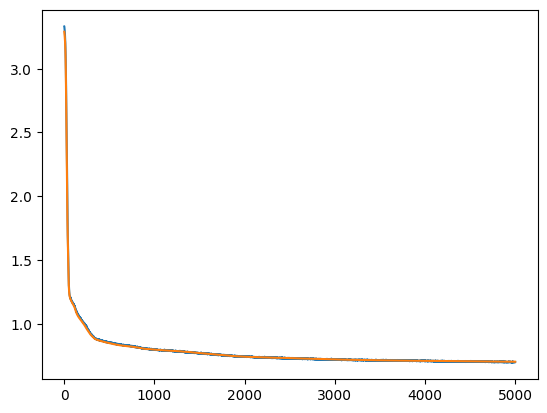

In [30]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

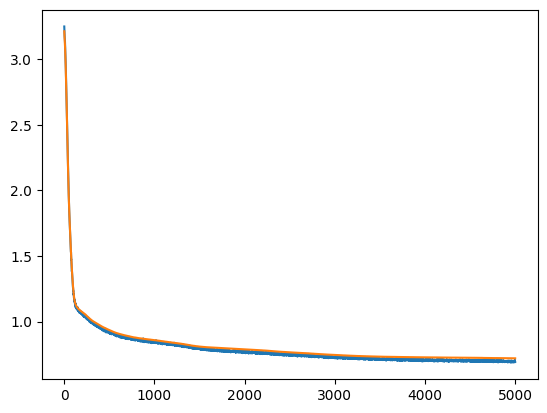

In [31]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

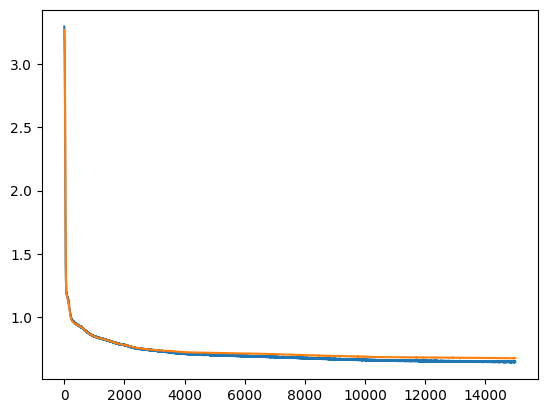

In [35]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

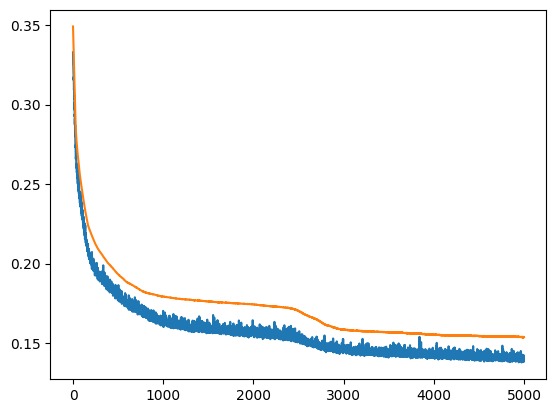

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

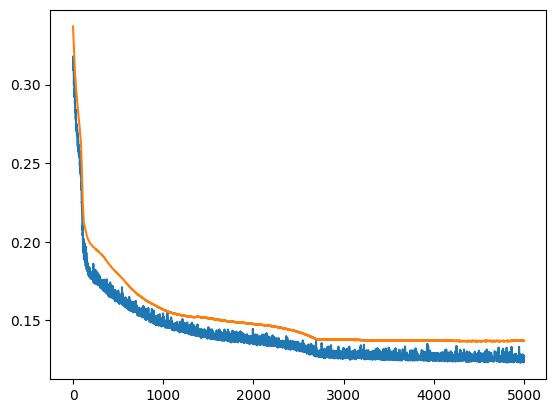

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

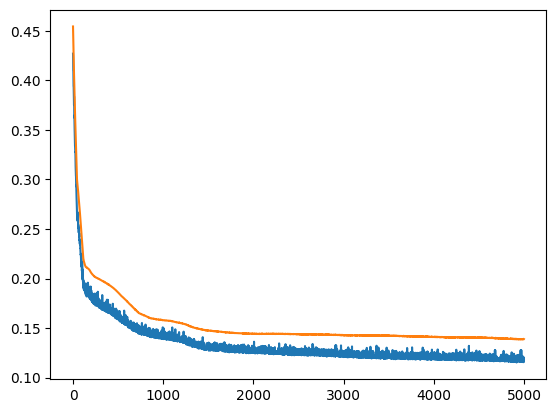

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

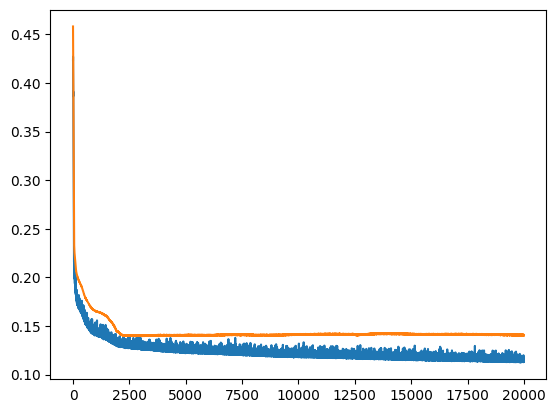

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

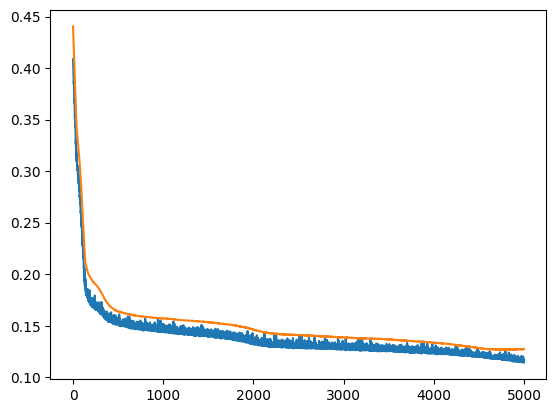

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Prediction on test set

In [31]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [32]:
#lab

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [33]:
#out

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [34]:
#res

To calculate mean error on consecutive coordinates run:

In [35]:
torch.mean(res, axis=0) 

tensor([0.1637, 0.1429, 0.0781, 0.2544, 0.1106, 0.0522, 0.2097, 0.1124],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [36]:
torch.mean(res)

tensor(0.1405, device='cuda:0', grad_fn=<MeanBackward0>)

### Visualisations

In [37]:
dim_nr = 5
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

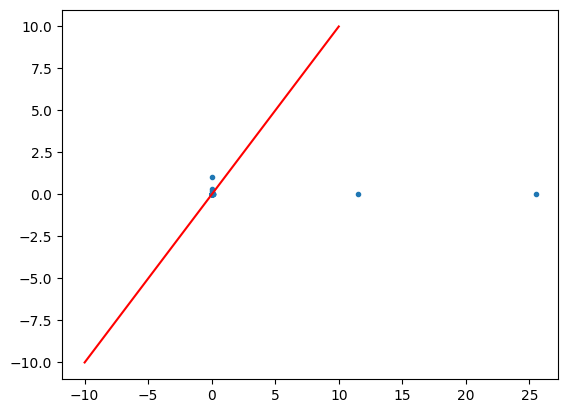

In [38]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [39]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [40]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [41]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_12189/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_12189/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_12189/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [42]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [43]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [44]:
len(closest)

780

In [45]:
y_test_df['Closest'] = closest

In [46]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

559

In [47]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.7166666666666667

#### Now let's check if it works for the neural network's output.

In [48]:
model.eval()
outputs = model(X_test)

In [49]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [50]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [51]:
len(closest)

780

In [52]:
outputs_df['Closest'] = closest

In [53]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

31

In [54]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.03974358974358974

## Quality of prediction: confidence intervals

In [55]:
model.eval()
outputs = model(X_test)

In [56]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [57]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [58]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_12189/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_12189/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_12189/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [59]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_12189/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_12189/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_12189/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [60]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [61]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [62]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [63]:
np.array(sd_res_list).mean()

0.28509615384615383

On consecutive coordinates:

In [72]:
np.array(sd_res_list).mean(0)

array([[0.38461538, 0.29358974, 0.42564103, 0.21025641, 0.16666667,
        0.25512821, 0.23846154, 0.33974359]])

Percentage of points inside min-max interval:

In [65]:
np.array(min_max_res_list).mean()

0.21570512820512822

On consecutive coordinates:

In [66]:
np.array(min_max_res_list).mean(0)

array([[0.37051282, 0.23589744, 0.07307692, 0.24871795, 0.15769231,
        0.15      , 0.2525641 , 0.23717949]])

### Visualisations of mean +- 2 * standard deviation intervals

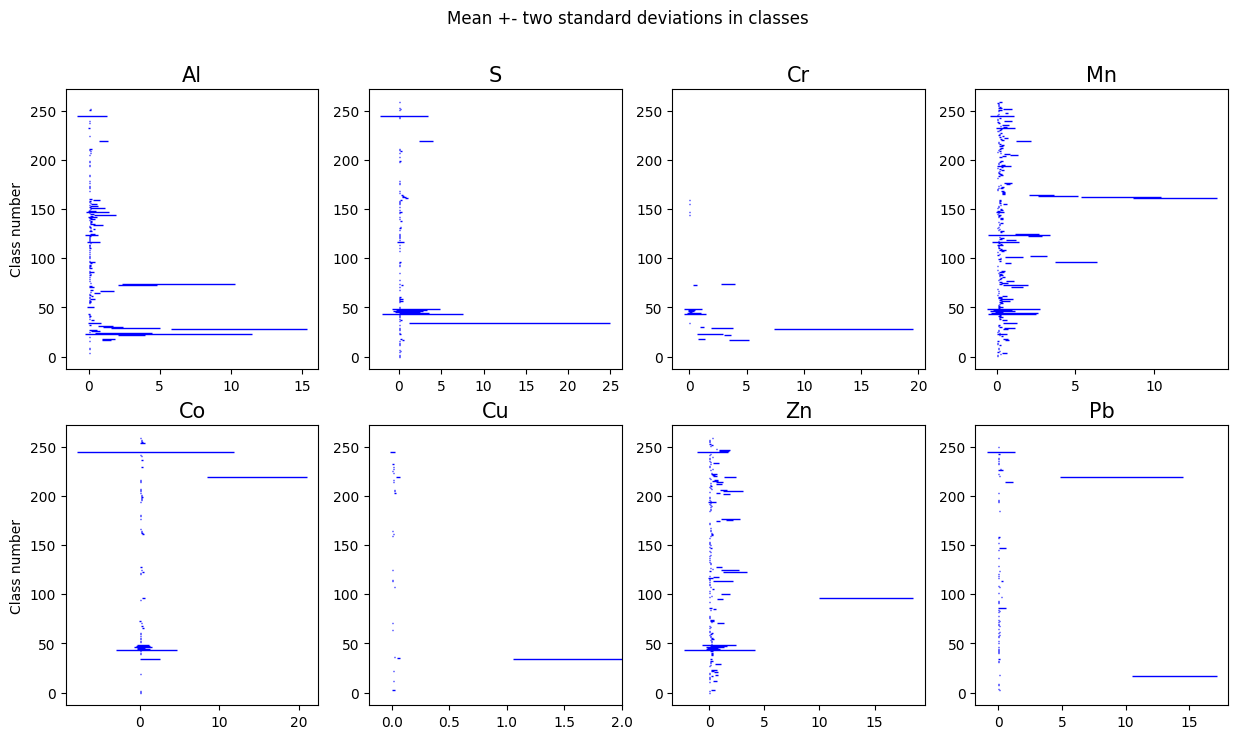

In [67]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

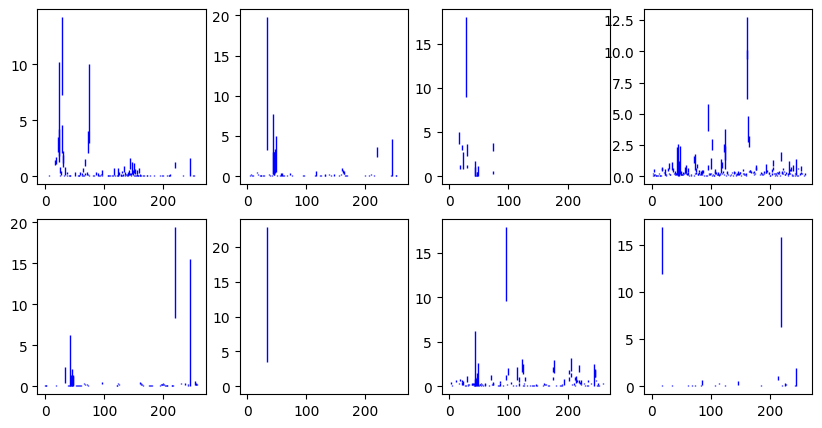

In [68]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

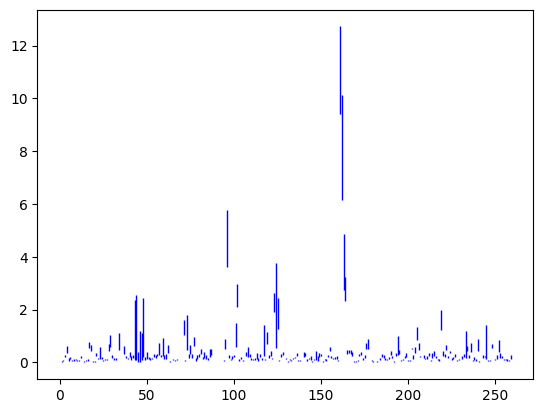

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Prediction on the real dataset (without ground truth)

In [ ]:
object_name == 'Konstytucja'

In [ ]:
target_df = pd.ExcelFile(data_path[object_name])
target_df = target_df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(0, 3945))
target_df.columns = target_df.parse('Arkusz1', header=None, usecols=range(32,59), nrows=1).values[0]

In [ ]:
target_df = target_df.reset_index(drop=False)

In [ ]:
target_df['Sample_id'] = np.repeat(range(int(target_df.shape[0]/15)), 15, axis=0)

In [ ]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

In [ ]:
target_df = target_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

In [ ]:
(target_df.shape[0] - target_df.dropna().shape[0])/target_df.shape[0]

In [ ]:
target_df.dropna(inplace=True)

## Interpretability